<a href="https://colab.research.google.com/github/sabithakrishnan/timeseries-analysis/blob/main/timeseries_analysis_transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_1760/440543559.py:13: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv("/content/AirQualityUCI.csv", sep=';', decimal=',', parse_dates=[['Date', 'Time']], dayfirst=True)
/tmp/ipykernel_1760/440543559.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv("/content/AirQualityUCI.csv", sep=';', decimal=',', parse_dates=[['Date', 'Time']], dayfirst=True)
/tmp/ipykernel_1760/440543559.py:26: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ts_data = df['CO(GT)'].ffill().astype(fl

R-squared: 0.4961
Adjusted R-squared: 0.4947
RMSE: 0.6628
MAE: 0.5073


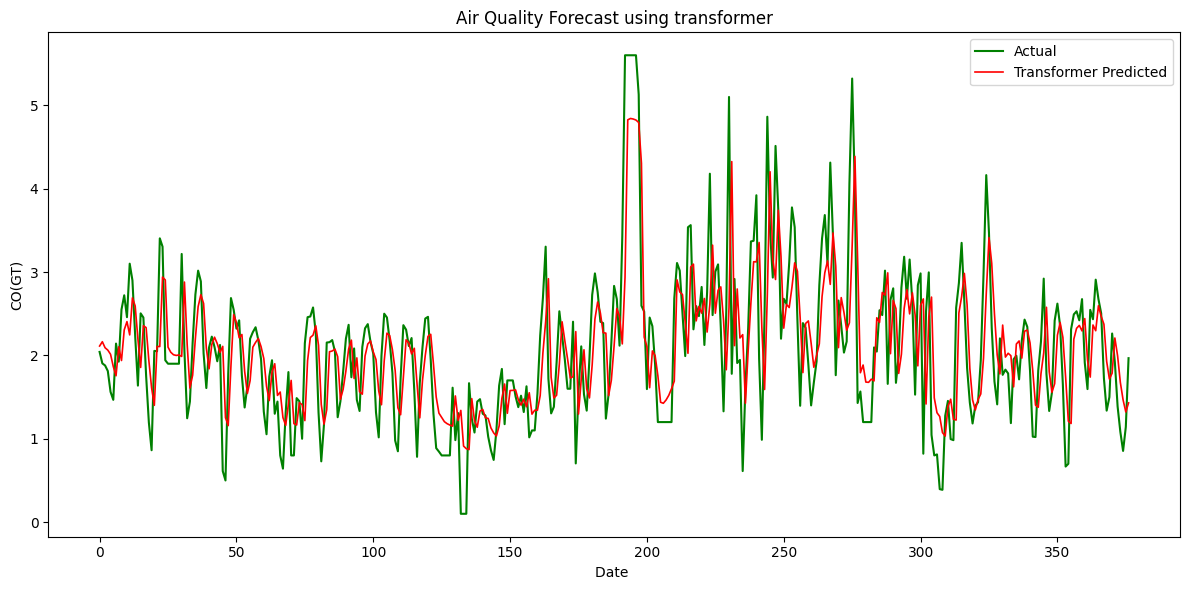

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# Set random seed for reproducibility
#torch.manual_seed(42)
#np.random.seed(42)

# Load  Dataset
df = pd.read_csv("/content/AirQualityUCI.csv", sep=';', decimal=',', parse_dates=[['Date', 'Time']], dayfirst=True)

# Data Preprocessing
df.dropna(how='all', inplace=True)
df = df.iloc[:, :15]

# Convert and index datetime
df['Date_Time'] = pd.to_datetime(df['Date_Time'], format='%d/%m/%Y %H.%M.%S', errors='coerce')
df.dropna(subset=['Date_Time'], inplace=True)
df.set_index('Date_Time', inplace=True)

# Replace missing values (-200) and forward fill
df.replace(-200, pd.NA, inplace=True)
ts_data = df['CO(GT)'].ffill().astype(float)

# Resample to daily frequency to match target density
ts_data = ts_data.resample('D').mean().ffill().values.reshape(-1, 1)

# Transformers are highly sensitive to unscaled input data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(ts_data)

# Create Windowed Sequences for Supervised Learning
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i : i + seq_length])
        y.append(data[i + seq_length])
    return torch.tensor(np.array(X), dtype=torch.float32), torch.tensor(np.array(y), dtype=torch.float32)

seq_length = 14  # Look back at the past 14 days
X_tensor, y_tensor = create_sequences(scaled_data, seq_length)

#  Build the Time Series Transformer Model
class TimeSeriesTransformer(nn.Module):
    def __init__(self, input_dim=1, d_model=32, nhead=4, num_layers=2, dim_feedforward=64):
        super(TimeSeriesTransformer, self).__init__()
        # Linear layer acts as an embedding project layer for single element steps
        self.input_linear = nn.Linear(input_dim, d_model)

        # Transformer Encoder Stack
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward, batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Linear map projection back to prediction dimension
        self.output_linear = nn.Linear(d_model, 1)

    def forward(self, x):
        x = self.input_linear(x)
        x = self.transformer_encoder(x)
        # Take the output state of the final time step in the window sequence
        out = self.output_linear(x[:, -1, :])
        return out

model = TimeSeriesTransformer()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

# Train the Neural Network Model
epochs = 80
model.train()
for epoch in range(epochs):
    optimizer.zero_grad()
    output = model(X_tensor)
    loss = criterion(output, y_tensor)
    loss.backward()
    optimizer.step()

model.eval()
#Prediction
with torch.no_grad():
    scaled_predictions = model(X_tensor).numpy()
predictions = scaler.inverse_transform(scaled_predictions)
actual_values = scaler.inverse_transform(y_tensor.numpy())
#Accuracy metrics
# R-squared
r2 = r2_score(actual_values, predictions)

# Adjusted R-squared
# n = number of observations, k = number of independent variables (features)
n = len(actual_values)
k = 1
adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - k - 1))

# RMSE (Root Mean Squared Error)
rmse = np.sqrt(mean_squared_error(actual_values, predictions))

# MAE (Mean Absolute Error)
mae = mean_absolute_error(actual_values, predictions)
print(f"R-squared: {r2:.4f}")
print(f"Adjusted R-squared: {adj_r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
#Display results
plt.figure(figsize=(12, 6), dpi=100)
plt.plot(actual_values, label='Actual', color='green', linewidth=1.5)
plt.plot(predictions, label='Transformer Predicted', color='red',linewidth=1.2)
plt.title('Air Quality Forecast using transformer', fontsize=12)
plt.xlabel('Date ', fontsize=10)
plt.ylabel('CO(GT)', fontsize=10)
plt.legend(loc='upper right')
# Display final graph
plt.tight_layout()
plt.show()
